# Tempest Extremes Tutorial

This notebook works through a complete TCTrack workflow using
[Tempest
Extremes](https://tctrack.readthedocs.io/en/latest/tracking-algorithms/tempest_extremes.html)
to detect and track tropical cyclones in ERA5 reanalysis data.

We start by installing the tracker, then obtain and preprocess the example data,
run the tracking, and finally visualise the resulting tracks.

## Installing Tempest Extremes

First we need to install the underlying Tempest Extremes software.

This requires a C++ compiler, CMake, and NetCDF with C++ bindings to be installed.
If these are not included on your system and you are using conda they can be installed with:
```
conda install -c conda-forge cxx-compiler cmake netcdf-cxx
```

To install Tempest Extremes we use the
[`install_tempest_extremes.sh`](https://github.com/Cambridge-ICCS/TCTrack/blob/main/tutorial/install_tempest_extremes.sh)
script, which will clone and build Tempest Extremes locally under the tutorial
directory, as described on the build. Read the script carefully to understand and
check that you are happy with what it will do before running the cell.

Finally, it will update the `PATH` to make the Tempest Extremes executables available.

Note: while the `PATH` is updated by the script, this is not inherited by the
notebook. Hence why we do it again here.

In [1]:
import os
import subprocess

subprocess.run(["./install_tempest_extremes.sh"], check=True)

os.environ["PATH"] = f"{os.getcwd()}/tempestextremes/build/bin:{os.environ['PATH']}"

Tempest Extremes is already installed, skipping installation.


## Obtaining Data

We will use example data from the ERA5 reanalysis dataset from 1950-09-01 to
1950-09-07.

The following cell downloads a pre-prepared bundle from the TCTrack GitHub
releases and extracts the NetCDF files into a `data/` directory using the
`fetch_data` function from `fetch_data.py`.

The data can alternatively be downloaded from the [Copernicus Climate Data
Store](https://cds.climate.copernicus.eu). There is another function in
`fetch_data.py` to do this, but this requires an account and API key.

In [2]:
from fetch_data import fetch_data

fetch_data()

Done.


## Preprocessing of Data

The data now needs to be preprocessed into the form [required by Tempest
Extremes](https://tctrack.readthedocs.io/en/latest/tracking-algorithms/tempest_extremes.html#input-data).

We need the following variables:

* Mean sea-level pressure
* Geopotential at 300 and 500 hPa
* Orography (surface altitude)
* Surface windspeed

The first two are already included in the downloaded data. The orography can be
calculated from the surface geopotential and the windspeed can be calculated from the
10m wind components. This will be done here using the [preprocessing helper
functions](https://tctrack.readthedocs.io/en/latest/api/preprocessing_api.html).

The preprocessed data will be put in `data_processed/`.

In [3]:
import cf

from tctrack import preprocessing

# Specify file structure
data_in_dir = "data"
data_dir = "data_processed"
os.makedirs(data_dir, exist_ok=True)

Write the geopotential and sea-level pressure to the output directory and load the
surface wind speed components.

In [4]:
preprocessing.read_files(f"{data_in_dir}/era5_z.nc", output_file=f"{data_dir}/z.nc")

field_u10, field_v10 = preprocessing.separate_variables(
    f"{data_in_dir}/era5_sfc.nc",
    output_files={"msl": f"{data_dir}/msl.nc"},
    return_order=["u10", "v10"],
)

Calculate the surface wind speed from its components. We will use the ECMWF netcdf
variable name (`si10`).

In [5]:
preprocessing.calculate_wind_speed(
    field_u10, field_v10, nc_name="si10", output_file=f"{data_dir}/si10.nc"
)
del field_u10, field_v10  # free memory

Calculate the orography from the surface geopotential. The field is also squeezed to
remove the size-1 time dimension.

In [6]:
GRAVITY = 9.80665  # Standard gravitational acceleration [m s-2]

field_orog = preprocessing.squeeze_field(f"{data_in_dir}/era5_sfc_z.nc")
field_orog = preprocessing.multiply_field(field_orog, 1 / GRAVITY)
field_orog = preprocessing.set_netcdf_info(
    field_orog,
    nc_name="orog",
    properties={
        "standard_name": "surface_altitude",
        "long_name": "Surface Altitude",
        "units": "m",
    },
    output_file=f"{data_dir}/orog.nc",
)
del field_orog  # free memory

## Running the code

To run Tempest Extremes over the data we set up the detection and stitching
parameters, using the parameters from the [[Ullrich2021]](https://tctrack.readthedocs.io/en/latest/references.html#ullrich2021)
paper, then run the tracker.

First we need to load the `tempest_extremes` module.

In [7]:
import tctrack.tempest_extremes as te

input_files = [
    f"{data_dir}/z.nc",
    f"{data_dir}/msl.nc",
    f"{data_dir}/si10.nc",
    f"{data_dir}/orog.nc",
]

Now we define the parameters for the detection step. This identifies finding storm
candidates at each time step.

This involves finding minima in the sea-level pressure and then seeing if there are
closed contours around them for which the pressure and geopotential change by more
than a threshold amount (`delta`). Refer to the
[TEDetectParameters](https://tctrack.readthedocs.io/en/latest/api/tempest_extremes_api.html#tctrack.tempest_extremes.TEDetectParameters)
documentation for further information about the various parameters.

Note: The paper uses the difference in geopotential *height* between 300 and 500 hPa.
Whereas our data is just the geopotential. Hence, why the threshold value is scaled by
the gravitational acceleration. It also uses the `_DIFF` operation [provided by the
Tempest Extremes
software](https://climate.ucdavis.edu/tempestextremes.php#VariableExpressions).

In [8]:
closed_contours = [
    te.TEContour(var="msl", delta=200.0, dist=5.5, minmaxdist=0.0),
    te.TEContour(
        var="_DIFF(z(300hPa),z(500hPa))", delta=-6.0 * GRAVITY, dist=6.5, minmaxdist=1.0
    ),
]

output_commands = [
    te.TEOutputCommand(var="msl", operator="min", dist=0.0),
    te.TEOutputCommand(var="orog", operator="max", dist=0.0),
    te.TEOutputCommand(var="si10", operator="max", dist=2.0),
]

detect_parameters = te.TEDetectParameters(
    in_data=input_files,
    search_by_min="msl",
    time_filter="6hr",
    merge_dist=6.0,
    closed_contours=closed_contours,
    lat_name="latitude",
    lon_name="longitude",
    out_header=True,
    output_commands=output_commands,
)

Next, define the parameters for the stitching. This combines individual storm
candidates into tracks. It then filters based upon track length and checking that
certain threshold values are satisfied for a number of points along the track
(`threshold_filters`).

Refer to the
[TEStitchParameters](https://tctrack.readthedocs.io/en/latest/api/tempest_extremes_api.html#tctrack.tempest_extremes.TEStitchParameters)
documentation for further information about the various parameters.

In [9]:
threshold_filters = [
    te.TEThreshold(var="lat", op="<=", value=50, count=10),
    te.TEThreshold(var="lat", op=">=", value=-50, count=10),
    te.TEThreshold(var="orog", op="<=", value=150, count=10),
    te.TEThreshold(var="si10", op=">=", value=10, count=10),
]

stitch_parameters = te.TEStitchParameters(
    caltype="standard",
    max_sep=8.0,
    min_time="54h",
    max_gap="24h",
    min_endpoint_dist=8.0,
    threshold_filters=threshold_filters,
)

Finally, create the Tempest Extremes tracker object with our defined parameters and
run the tracker. Saving the results to `tracks_tempest_extremes.nc`.

In [10]:
te_tracker = te.TETracker(detect_parameters, stitch_parameters)
te_tracker.run_tracker("tracks_tempest_extremes.nc")

Executing DetectNodes...
DetectNodes completed successfully.
First 12 lines of output:
Arguments:
  --in_data <string> ["data_processed/z.nc;data_processed/msl.nc;data_processed/si10.nc;data_processed/orog.nc"] 
  --in_data_list <string> [""] 
  --in_connect <string> [""] 
  --diag_connect <bool> [false] 
  --out <string> ["/tmp/tmpsdivy2iz/nodes.txt"] 
  --out_file_list <string> [""] 
  --searchbymin <string> ["msl"] (default PSL)
  --searchbymax <string> [""] 
  --searchbythreshold <string> [""] 
  --minlon <double> [0.000000] (degrees)
  --maxlon <double> [0.000000] (degrees)

...

Last 12 lines of output:
....Rejected (contour _DIFF(z(300hPa),z(500hPa))): 34
....Done
..Time 1950-09-07 18:00:00
....Total candidates: 7
....Rejected (  location): 0
....Rejected (    merged): 8103
....Rejected ( threshold): 0
....Rejected (contour msl): 101
....Rejected (contour _DIFF(z(300hPa),z(500hPa))): 34
....Done
..Done
------------------------------------------------------------

Executing Stitc

## Inspecting the output

The output file is a CF-NetCDF file containing the tracks, along with variables such
as wind speed and sea-level pressure along each track. The structure can be inspected
with `ncdump -h tracks_tempest_extremes.nc`, or read directly with cf-python:

In [11]:
tracks = cf.read("tracks_tempest_extremes.nc")
tracks

[<CF Field: air_pressure_at_mean_sea_level(trajectory(4), observation(23)) Pa>,
 <CF Field: long_name=longitudinal grid index(trajectory(4), observation(23))>,
 <CF Field: long_name=latitudinal grid index(trajectory(4), observation(23))>,
 <CF Field: surface_altitude(trajectory(4), observation(23)) m>,
 <CF Field: wind_speed(trajectory(4), observation(23)) m.s-1>]

In [12]:
for field in tracks:
    print(f"{field.long_name}: {field.shape}")

Mean sea level pressure: (4, 23)
longitudinal grid index: (4, 23)
latitudinal grid index: (4, 23)
Surface Altitude: (4, 23)
Wind Speed: (4, 23)


As can be seen there are a total of four tracks (`trajectory`), with the longest
having 23 points (`observation`). Any shorter tracks are padded up to this length.

## Visualising Results

Finally we can visualise the results by plotting the tracks on a map.

In [13]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

# Extract the wind speed field and its coordinates as arrays
wind_field = tracks.select_field("wind_speed")
lats = wind_field.coordinate("latitude").array
lons = wind_field.coordinate("longitude").array
times = wind_field.coordinate("time").dtarray
intensity = wind_field.array

# Get intensity metadata for labels
intensity_name = wind_field.get_property("long_name")
intensity_units = wind_field.get_property("units")
min_intensity = np.nanmin(intensity)
max_intensity = np.nanmax(intensity)

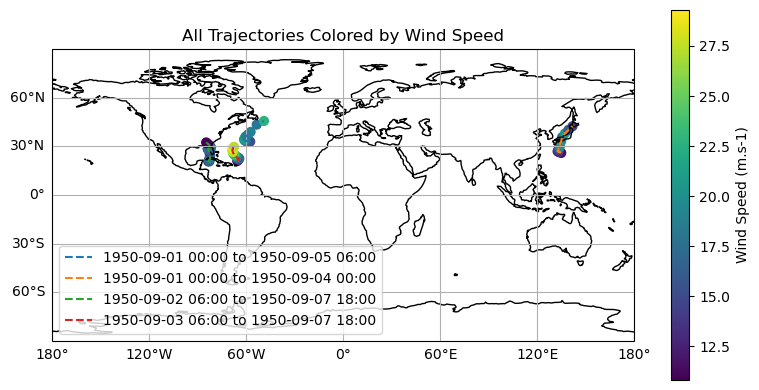

In [14]:
plt.figure(figsize=(8, 4))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, 90])
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True

# Plot each trajectory
for i in range(lats.shape[0]):
    times_i = times[i].compressed()
    label = (
        f"{times_i[0].strftime('%Y-%m-%d %H:%M')} to "
        f"{times_i[-1].strftime('%Y-%m-%d %H:%M')}"
    )
    mask = np.isfinite(lons[i])
    pl = ax.plot(
        lons[i, mask],
        lats[i, mask],
        "--",
        transform=ccrs.PlateCarree(),
        label=f"{label}",
    )
    sc = ax.scatter(
        lons[i],
        lats[i],
        c=intensity[i],
        cmap="viridis",
        s=40,
        vmin=min_intensity,
        vmax=max_intensity,
        transform=ccrs.PlateCarree(),
    )

plt.colorbar(sc, label=f"{intensity_name} ({intensity_units})")
plt.title(f"All Trajectories Colored by {intensity_name}")
plt.legend()
plt.tight_layout()
plt.show()